<a href="https://colab.research.google.com/github/safeai-snu/finance_ai_2025/blob/main/day4/TS_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [379]:
!pip install -q neuralforecast
!pip show neuralforecast

from neuralforecast.models import PatchTST
from neuralforecast import NeuralForecast
from neuralforecast.models import MLP
from neuralforecast.losses.pytorch import MAE
from neuralforecast.tsdataset import TimeSeriesDataset

import pytorch_lightning as pl
import matplotlib.pyplot as plt

Name: neuralforecast
Version: 3.0.0
Summary: Time series forecasting suite using deep learning models
Home-page: https://github.com/Nixtla/neuralforecast/
Author: Nixtla
Author-email: business@nixtla.io
License: Apache Software License 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: coreforecast, fsspec, numpy, optuna, pandas, pytorch-lightning, ray, torch, utilsforecast
Required-by: 


## Toy Example

In [380]:
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import matplotlib.pyplot as plt

from neuralforecast import NeuralForecast
from neuralforecast.models import MLP
from neuralforecast.losses.pytorch import MQLoss, DistributionLoss
from neuralforecast.tsdataset import TimeSeriesDataset
from neuralforecast.utils import AirPassengers, AirPassengersPanel, AirPassengersStatic, augment_calendar_df

AirPassengersPanel, calendar_cols = augment_calendar_df(df=AirPassengersPanel, freq='M')

Y_train_df = AirPassengersPanel[AirPassengersPanel.ds<AirPassengersPanel['ds'].values[-12]] # 132 train
Y_test_df = AirPassengersPanel[AirPassengersPanel.ds>=AirPassengersPanel['ds'].values[-12]].reset_index(drop=True) # 12 test

In [381]:
Y_train_df

,unique_id,ds,y,trend,y_[lag12],month
0,Airline1,1949-01-31,112.0,0,112.0,-0.500000
1,Airline1,1949-02-28,118.0,1,118.0,-0.409091
2,Airline1,1949-03-31,132.0,2,132.0,-0.318182
3,Airline1,1949-04-30,129.0,3,129.0,-0.227273
4,Airline1,1949-05-31,121.0,4,121.0,-0.136364
...,...,...,...,...,...,...
271,Airline2,1959-08-31,859.0,271,805.0,0.136364
272,Airline2,1959-09-30,763.0,272,704.0,0.227273
273,Airline2,1959-10-31,707.0,273,659.0,0.318182
274,Airline2,1959-11-30,662.0,274,610.0,0.409091


In [382]:
Y_test_df

,unique_id,ds,y,trend,y_[lag12],month
0,Airline1,1960-01-31,417.0,132,360.0,-0.500000
1,Airline1,1960-02-29,391.0,133,342.0,-0.409091
2,Airline1,1960-03-31,419.0,134,406.0,-0.318182
3,Airline1,1960-04-30,461.0,135,396.0,-0.227273
4,Airline1,1960-05-31,472.0,136,420.0,-0.136364
5,Airline1,1960-06-30,535.0,137,472.0,-0.045455
6,Airline1,1960-07-31,622.0,138,548.0,0.045455
7,Airline1,1960-08-31,606.0,139,559.0,0.136364
8,Airline1,1960-09-30,508.0,140,463.0,0.227273
9,Airline1,1960-10-31,461.0,141,407.0,0.318182


In [378]:
from neuralforecast.models import NBEATS, NHITS, PatchTST
#from neuralforecast.models import DLinear, Autoforemr, Informer, DeepAR, iTransformer

horizon = 12

# ▒▒▒ Step 2: 모델 정의 ▒▒▒
models = [
    NBEATS(h=horizon, input_size=2*horizon, loss=MAE(), max_steps=300),
    NHITS(h=horizon, input_size=2*horizon, loss=MAE(), max_steps=300),
    #PatchTST(h=horizon, input_size=2*horizon, loss=MAE(), max_steps=300),
    PatchTST(h=horizon,
            input_size=2*horizon,
            patch_len=24,
            stride=24,
            revin=False,
            hidden_size=16,
            n_heads=4,
            scaler_type='robust',
            loss=MAE(),
            learning_rate=1e-3,
            max_steps=300,
            val_check_steps=50,
            early_stop_patience_steps=2)
]

# ▒▒▒ Step 3: 학습 ▒▒▒
nf = NeuralForecast(models=models, freq='M')
nf.fit(df=Y_train_df, val_size=horizon)

# ▒▒▒ Step 4: 예측 ▒▒▒
forecasts = nf.predict(futr_df=Y_test_df)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.4 M  | train
-------------------------------------------------------
2.4 M     Trainable params
900       Non-trainable params
2.4 M     Total params
9.789     Total estimated mo

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [418]:
from sklearn.metrics import mean_absolute_error

mae_scores = {}
for col in forecasts.columns:
    if col.startswith('ds') or col.startswith('unique_id'):
        continue
    y_true = Y_test_df[Y_test_df['unique_id']=='Airline1']['y'].values
    y_pred = forecasts[forecasts['unique_id'] == 'Airline1'][col].values
    y_pred = y_pred[:len(y_true)]
    mae_scores[col] = mean_absolute_error(y_true, y_pred)

print("MAE Scores:")
for model, score in mae_scores.items():
    print(f"{model}: {score:.3f}")

MAE Scores:
NBEATS: 18.978
NHITS: 18.941
PatchTST: 17.073


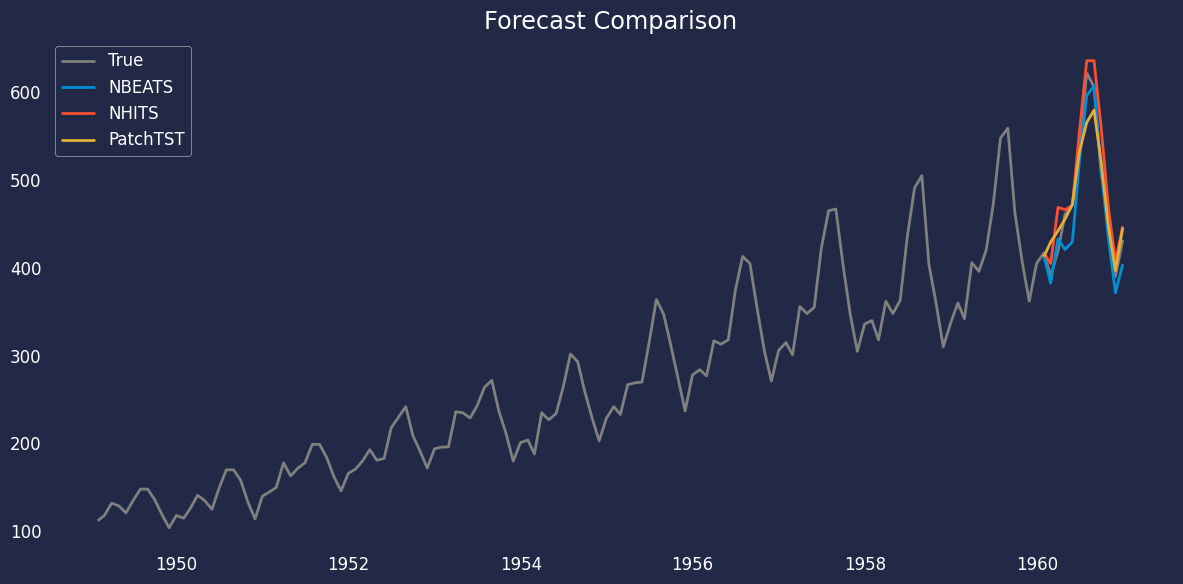

In [419]:
# ▒▒▒ Step 6: 시각화 ▒▒▒
import matplotlib.pyplot as plt

Y_hat_df = forecasts.reset_index(drop=True).drop(columns=['unique_id','ds'])
plot_df_nf = pd.concat([Y_test_df.reset_index(drop=True), Y_hat_df], axis=1)
plot_df = pd.concat([Y_train_df, plot_df_nf])

plot_df = plot_df[plot_df['unique_id'] == 'Airline1']

plt.figure(figsize=(12, 6))
plt.plot(plot_df['ds'], plot_df['y'], label='True', c='grey')

for col in forecasts.columns:
    if 'median' in col or col.startswith('ds') or col.startswith('unique_id'):
        continue
    if 'PatchTST' in col and '-lo-' in col:
        continue  # Skip low/high intervals for now
    plt.plot(plot_df['ds'], plot_df[col], label=col)

# 예: PatchTST의 신뢰구간 시각화
if 'PatchTST-median' in plot_df.columns:
    plt.plot(plot_df['ds'], plot_df['PatchTST-median'], label='PatchTST-median', c='blue')
    plt.fill_between(
        x=plot_df['ds'][-horizon:],
        y1=plot_df['PatchTST-lo-90'][-horizon:].values,
        y2=plot_df['PatchTST-hi-90'][-horizon:].values,
        alpha=0.3,
        label='PatchTST 90% CI'
    )

plt.legend()
plt.title("Forecast Comparison")
plt.grid()
plt.tight_layout()
plt.show()

## StatsForecast

In [386]:
!pip install statsforecast

In [420]:
import matplotlib.pyplot as plt

dark_style = {
    'figure.facecolor': '#212946',
    'axes.facecolor': '#212946',
    'savefig.facecolor': '#212946',
    'axes.grid': True,
    'axes.grid.which': 'both',
    'grid.color': '#2A3459',
    'grid.linewidth': 1,
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': False,
    'text.color': '#FFFFFF',
    'axes.labelcolor': '#FFFFFF',
    'xtick.color': '#FFFFFF',
    'ytick.color': '#FFFFFF',
    'font.size': 12,
    'lines.linewidth': 2
}
plt.rcParams.update(dark_style)

from pylab import rcParams
rcParams['figure.figsize'] = (18,7)

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

In [421]:
# df = pd.read_csv("https://raw.githubusercontent.com/Naren8520/Serie-de-tiempo-con-Machine-Learning/main/Data/candy_production.csv")
# df.head()

In [422]:
# df["unique_id"]="1"
# df.columns=["ds", "y", "unique_id"]
# df.head()

## Time Series Analysis

In [423]:
df_p = AirPassengersPanel

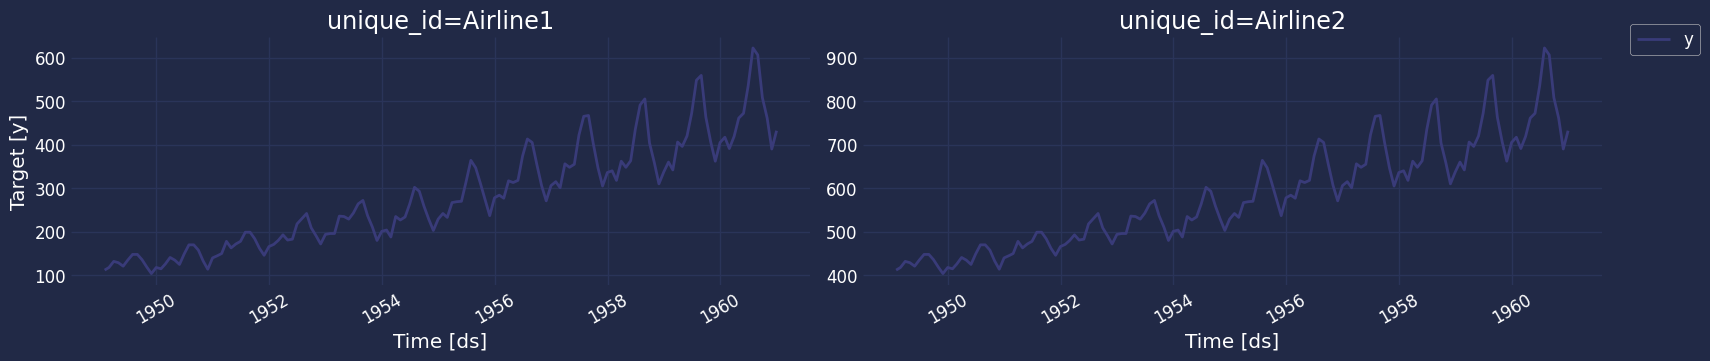

In [424]:
from statsforecast import StatsForecast

StatsForecast.plot(df_p)

,y
count,144.000000
mean,280.298615
std,119.966301
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


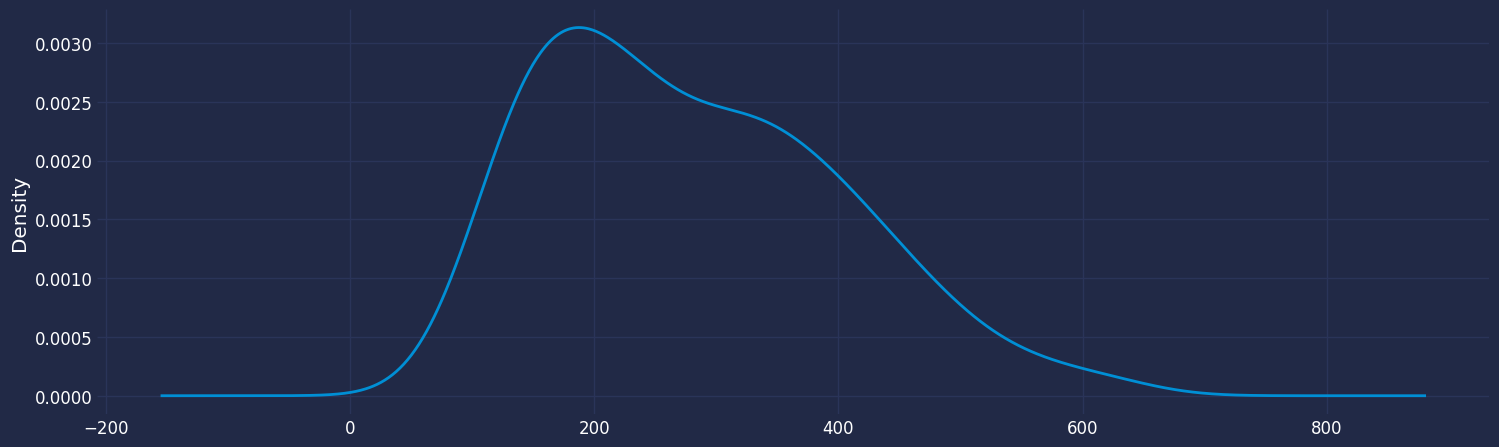

In [425]:
df = df_p[df_p['unique_id']=='Airline1']
df["y"].plot(kind='kde',figsize = (16,5))
df["y"].describe()

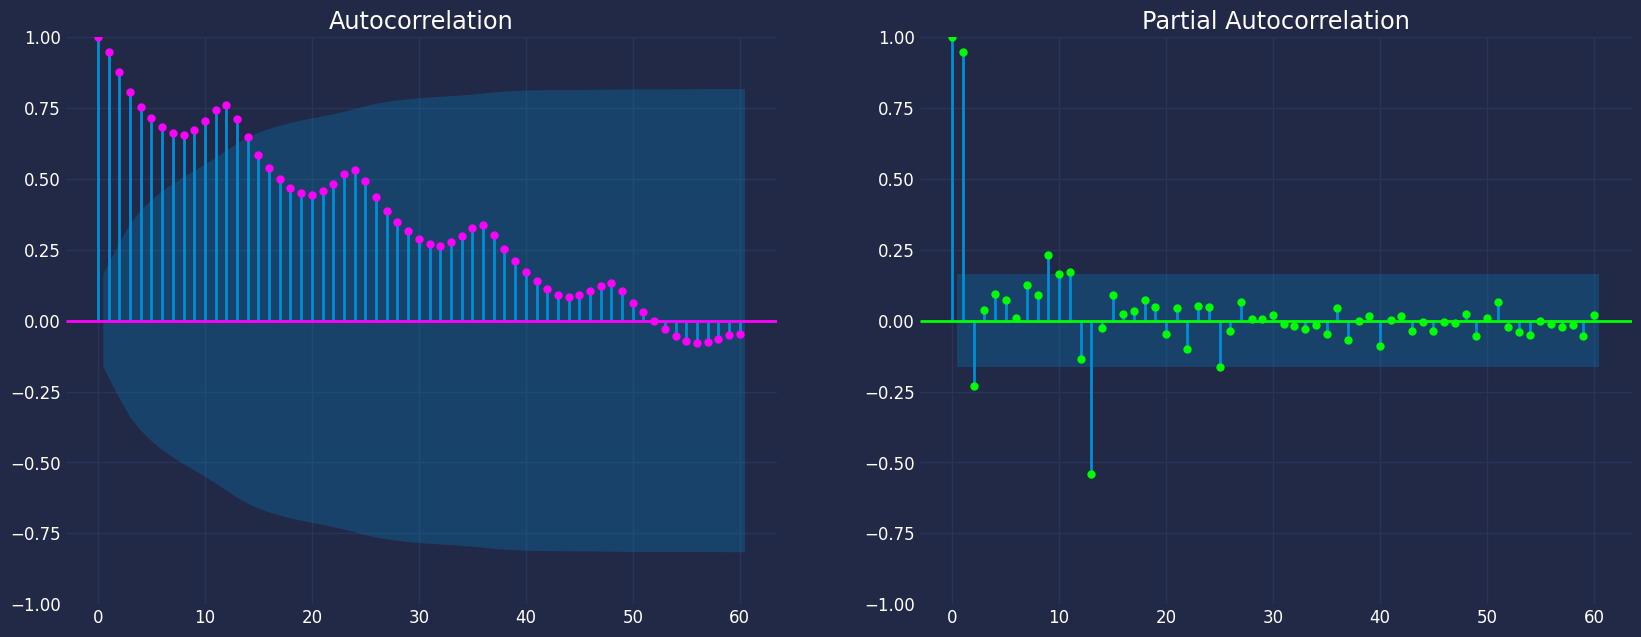

In [426]:
# Autocorrelation plot
fig, axs = plt.subplots(nrows=1, ncols=2)

plot_acf(df["y"],  lags=60, ax=axs[0],color="fuchsia")
axs[0].set_title("Autocorrelation");

plot_pacf(df["y"],  lags=60, ax=axs[1],color="lime")
axs[1].set_title('Partial Autocorrelation')

plt.show();

In [427]:
from statsmodels.tsa.seasonal import seasonal_decompose

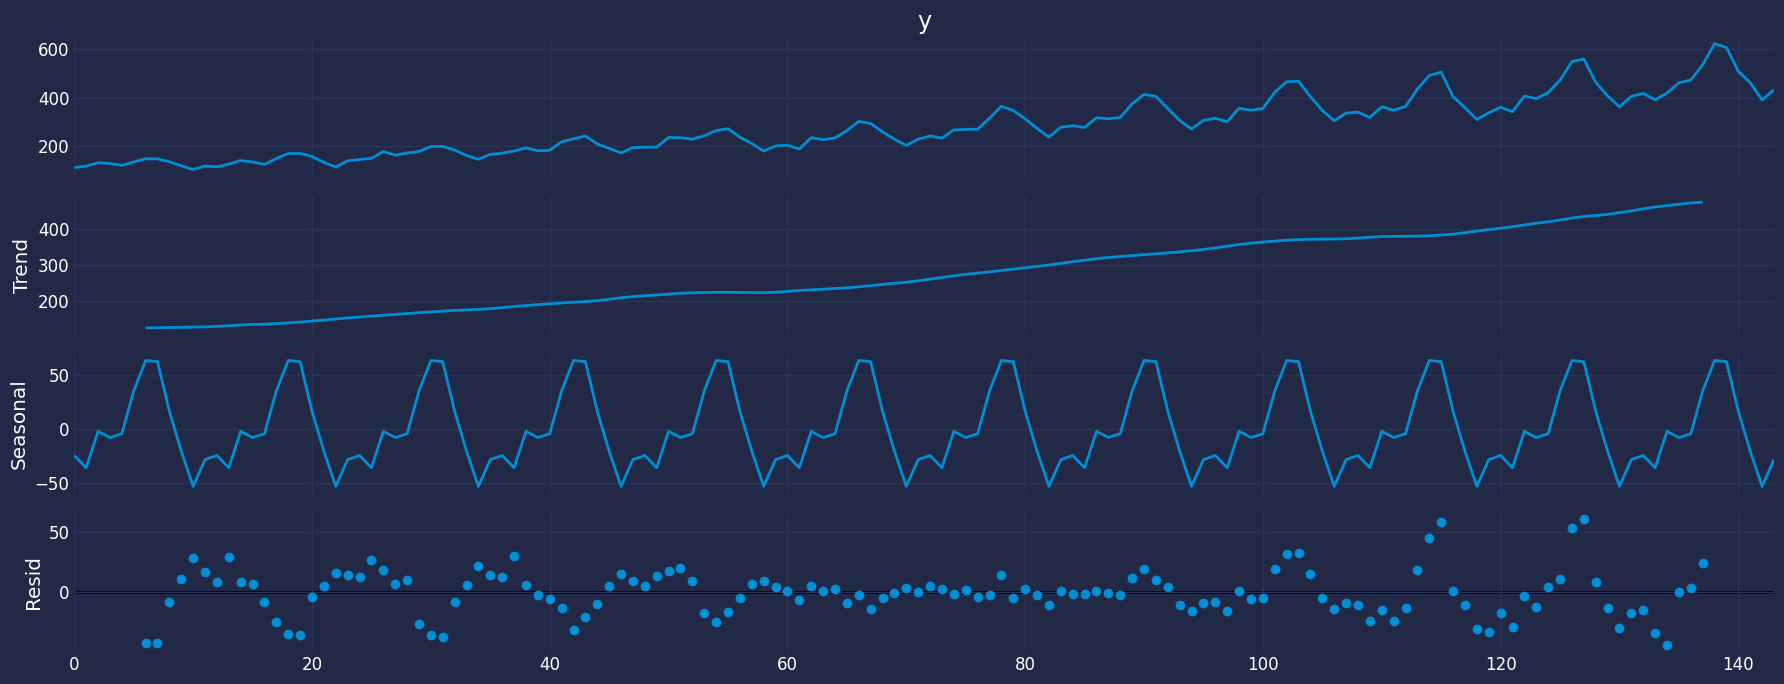

In [429]:
decomposed=seasonal_decompose(df["y"], model = "add", period=12)
decomposed.plot()
plt.show()

In [430]:
from statsmodels.tsa.stattools import adfuller

In [431]:
def Augmented_Dickey_Fuller_Test_func(series , column_name):
    print (f'Dickey-Fuller test results for columns: {column_name}')
    dftest = adfuller(series, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','No Lags Used','Number of observations used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
    if dftest[1] <= 0.05:
        print("Conclusion:====>")
        print("Reject the null hypothesis")
        print("The data is stationary")
    else:
        print("Conclusion:====>")
        print("The null hypothesis cannot be rejected")
        print("The data is not stationary")

In [432]:
Augmented_Dickey_Fuller_Test_func(df["y"],"Passengers")

Dickey-Fuller test results for columns: Passengers
Test Statistic                   0.815369
p-value                          0.991880
No Lags Used                    13.000000
Number of observations used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Conclusion:====>
The null hypothesis cannot be rejected
The data is not stationary


In [433]:
df1=df.copy()
df1['y_diff'] = df['y'].diff()
df1.dropna(inplace=True)
df1.head()

,unique_id,ds,y,trend,y_[lag12],month,y_diff
1,Airline1,1949-02-28,118.0,1,118.0,-0.409091,6.0
2,Airline1,1949-03-31,132.0,2,132.0,-0.318182,14.0
3,Airline1,1949-04-30,129.0,3,129.0,-0.227273,-3.0
4,Airline1,1949-05-31,121.0,4,121.0,-0.136364,-8.0
5,Airline1,1949-06-30,135.0,5,135.0,-0.045455,14.0


In [434]:
Augmented_Dickey_Fuller_Test_func(df1["y_diff"],"Passengers_diff")

Dickey-Fuller test results for columns: Passengers_diff
Test Statistic                  -2.829267
p-value                          0.054213
No Lags Used                    12.000000
Number of observations used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Conclusion:====>
The null hypothesis cannot be rejected
The data is not stationary


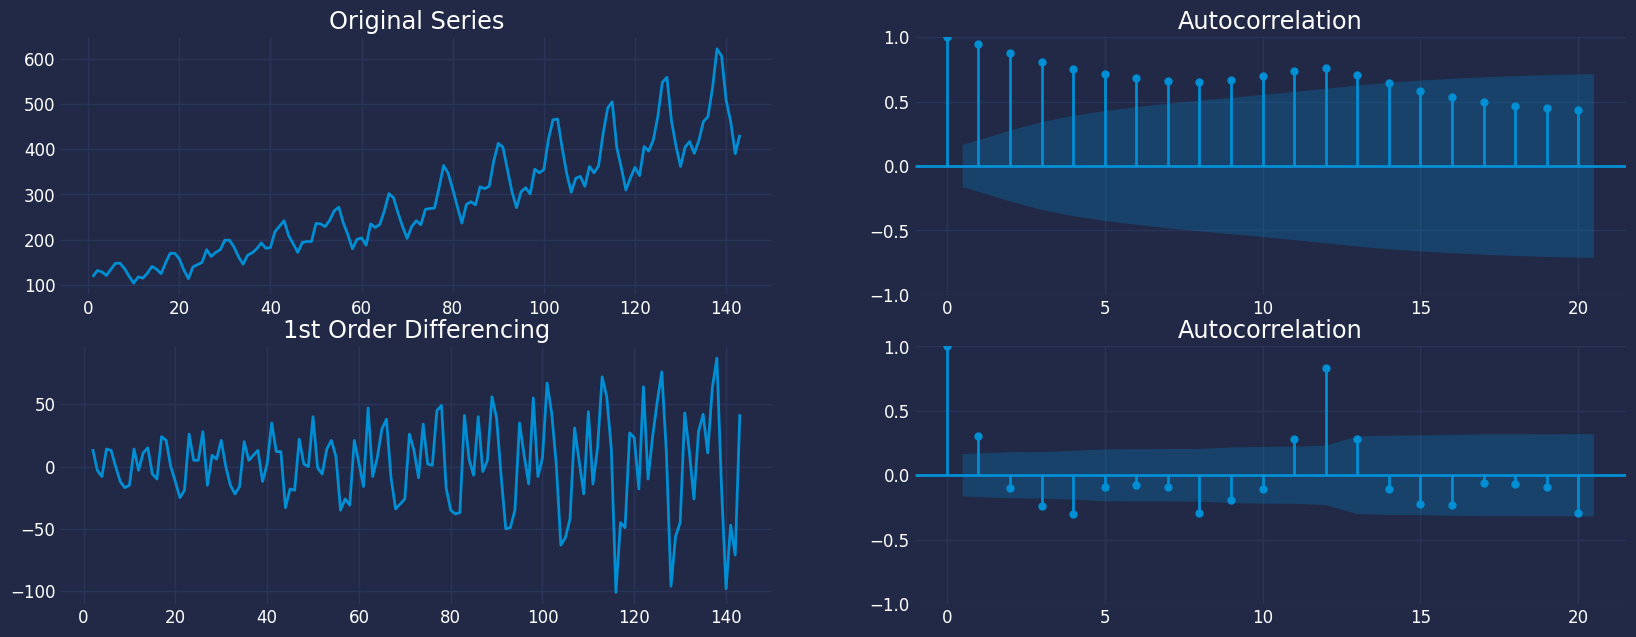

In [435]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, )
axes[0, 0].plot(df1["y"]); axes[0, 0].set_title('Original Series')
plot_acf(df1["y"], ax=axes[0, 1],lags=20)

axes[1, 0].plot(df1["y"].diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df1["y"].diff().dropna(), ax=axes[1, 1],lags=20)


plt.show()

In [402]:
## Model Evaluation

## Model Evaluation

In [436]:
df["ds"] = pd.to_datetime(df["ds"])

Y_train_df.shape, Y_test_df.shape

<ipython-input-436-b8aa2078b51d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ds"] = pd.to_datetime(df["ds"])


((264, 3), (24, 3))

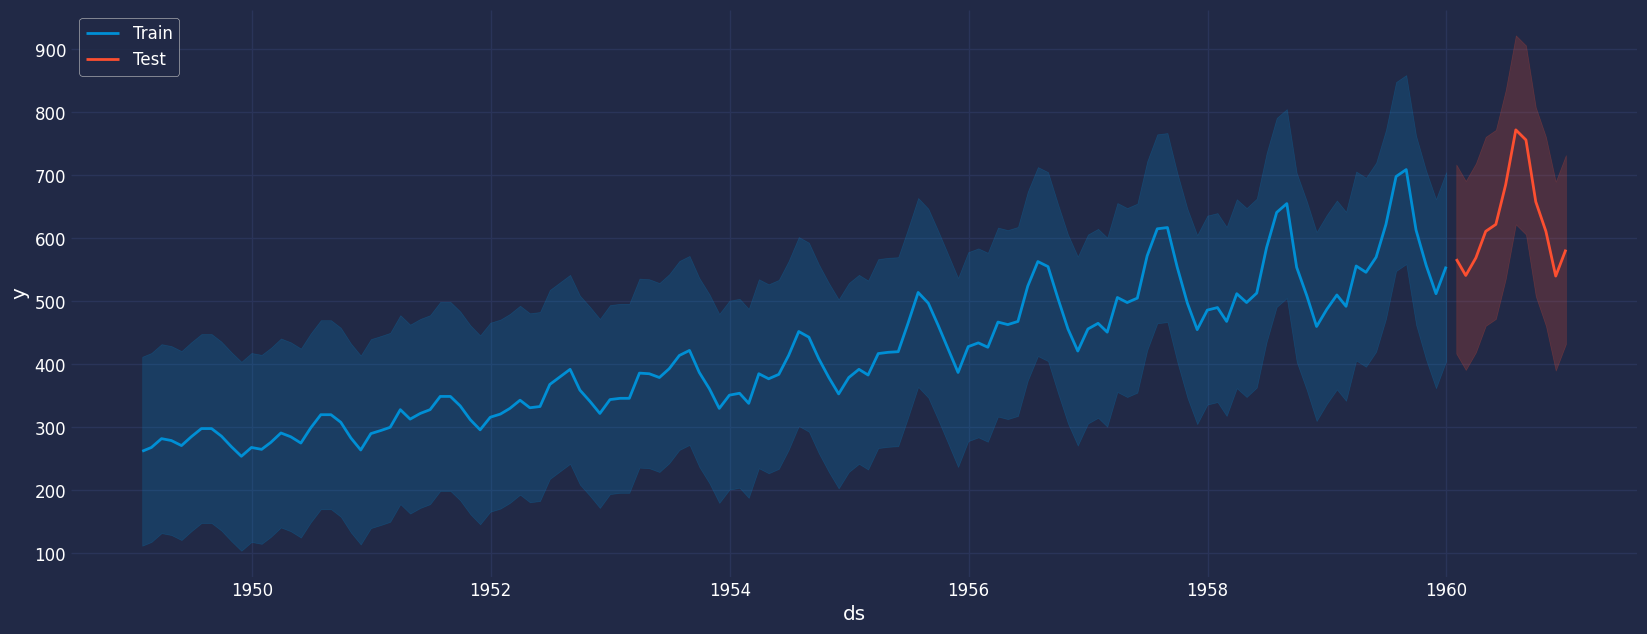

In [437]:
sns.lineplot(Y_train_df,x="ds", y="y", label="Train")
sns.lineplot(Y_test_df, x="ds", y="y", label="Test")
plt.show()

##  AutoARIMA, AutoETS, AutoTheta with StatsForecast

In [438]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta
from statsforecast.arima import arima_string

In [439]:
season_length = 12 # Monthly data
horizon = len(Y_test_df) # number of predictions

models = [AutoARIMA(season_length=season_length),
          AutoETS(model='ZZZ', season_length=season_length),
          AutoTheta(season_length=season_length,
                     decomposition_type="additive",
                     model="STM")]

In [440]:
sf = StatsForecast(models=models, freq='M')
sf.fit(df=Y_train_df)

StatsForecast(models=[AutoARIMA,AutoETS,AutoTheta])

In [441]:
arima_string(sf.fitted_[0,0].model_)

'ARIMA(1,1,0)(0,1,0)[12]                   '

In [442]:
#series index, model index
result=sf.fitted_[0,0].model_
print(result.keys())
print(result['arma'])

dict_keys(['coef', 'sigma2', 'var_coef', 'mask', 'loglik', 'aic', 'arma', 'residuals', 'code', 'n_cond', 'nobs', 'model', 'bic', 'aicc', 'ic', 'xreg', 'x', 'lambda'])
(1, 0, 0, 0, 12, 1, 1)


In [443]:
#series index, model index
result=sf.fitted_[0,2].model_
print(result.keys())

dict_keys(['mse', 'amse', 'fit', 'residuals', 'm', 'states', 'par', 'n', 'modeltype', 'mean_y', 'decompose', 'decomposition_type', 'seas_forecast', 'fitted'])


In [444]:
residual=pd.DataFrame(result.get("residuals"), columns=["residual Model"])
residual

,residual Model
0,88.837463
1,-17.467670
2,-19.915097
3,-2.363821
4,-17.249183
...,...
127,68.678997
128,-40.461005
129,-42.216655
130,-65.838836


<ipython-input-445-5137de7113d4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual, ax=axs[0,1]);


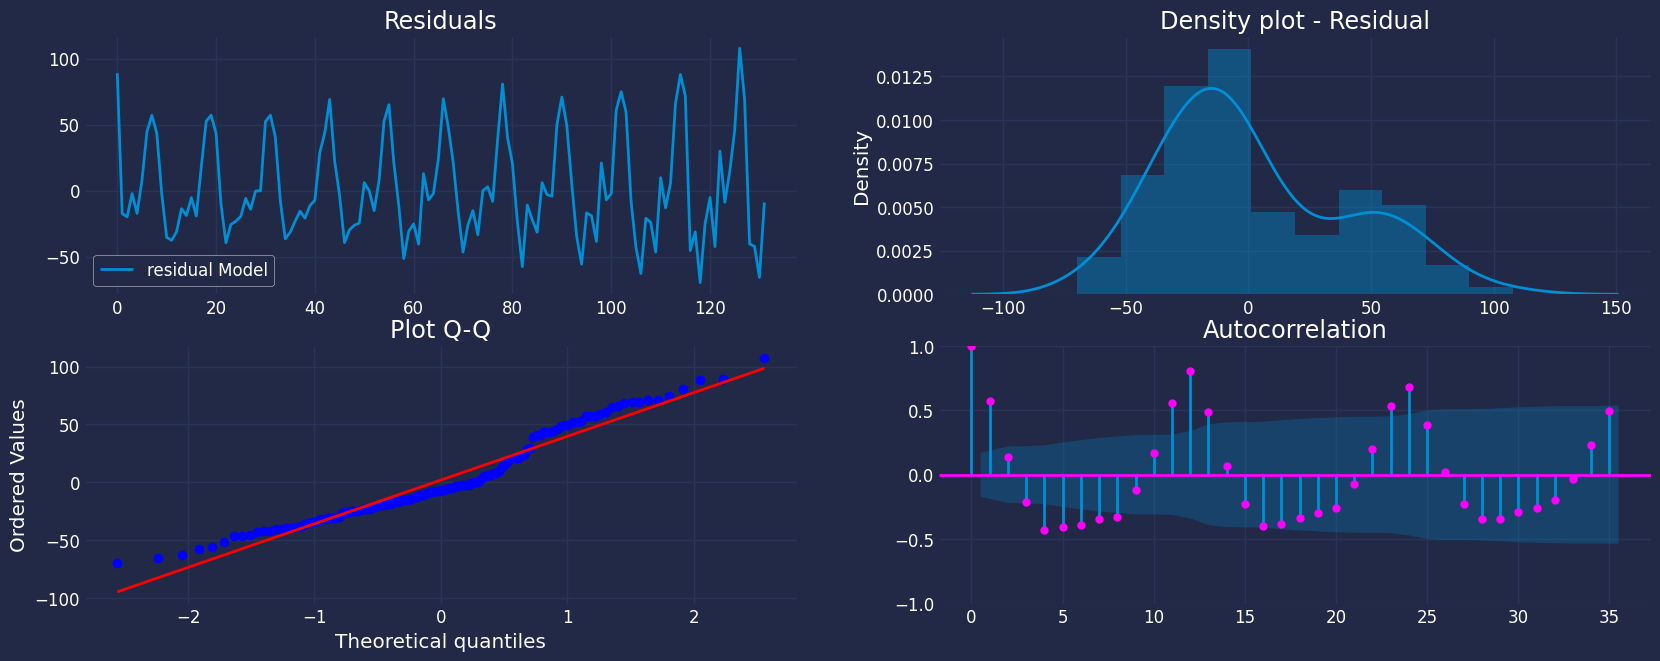

In [445]:
from scipy import stats


fig, axs = plt.subplots(nrows=2, ncols=2)

# plot[1,1]
residual.plot(ax=axs[0,0])
axs[0,0].set_title("Residuals");

# plot
sns.distplot(residual, ax=axs[0,1]);
axs[0,1].set_title("Density plot - Residual");

# plot
stats.probplot(residual["residual Model"], dist="norm", plot=axs[1,0])
axs[1,0].set_title('Plot Q-Q')

# plot
plot_acf(residual,  lags=35, ax=axs[1,1],color="fuchsia")
axs[1,1].set_title("Autocorrelation");

plt.show();

In [446]:
Y_train_df = Y_train_df[['unique_id', 'ds', 'y']]
Y_test_df = Y_test_df[['unique_id', 'ds', 'y']]

In [447]:
horizon = 12
Y_hat_df = sf.forecast(df=Y_train_df, h=horizon, fitted=True)

/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:384: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:440: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


In [448]:
Y_hat_df

,unique_id,ds,AutoARIMA,AutoETS,AutoTheta
0,Airline1,1960-01-31,424.083771,406.651276,409.732178
1,Airline1,1960-02-29,407.042328,401.732910,401.535187
2,Airline1,1960-03-31,470.807709,456.289642,437.742371
3,Airline1,1960-04-30,460.865143,440.870514,428.862030
4,Airline1,1960-05-31,484.851074,440.333923,433.269196
5,Airline1,1960-06-30,536.854553,496.866058,472.380524
6,Airline1,1960-07-31,612.853699,545.839111,499.200195
7,Airline1,1960-08-31,623.853882,544.672485,498.715698
8,Airline1,1960-09-30,527.853821,477.034485,458.922882
9,Airline1,1960-10-31,471.853851,412.423096,425.250885


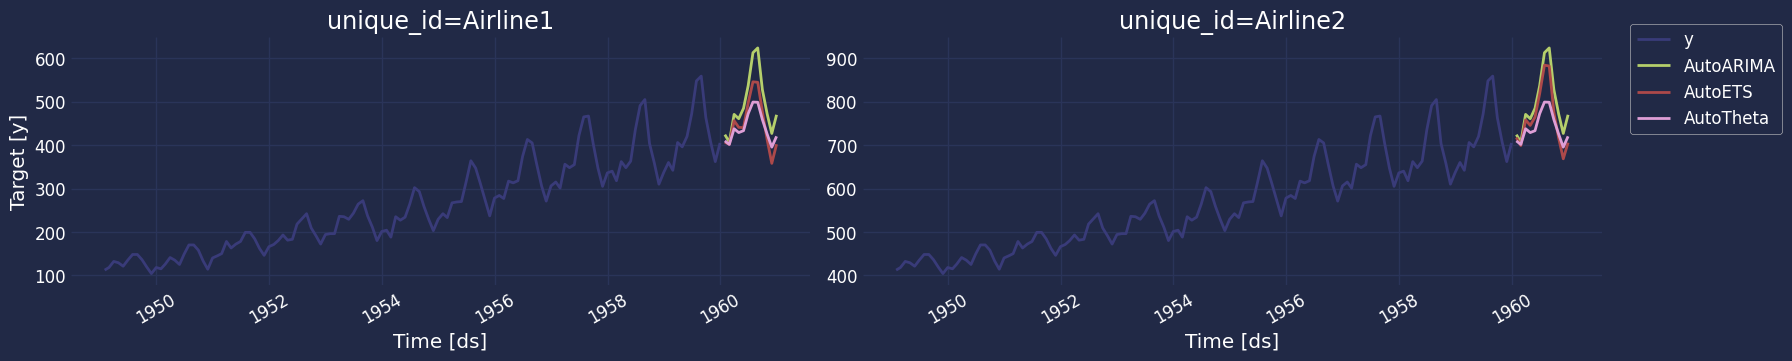

In [449]:
sf.plot(Y_train_df, Y_hat_df)

In [368]:
# values=sf.forecast_fitted_values()
# values

/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:384: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:440: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


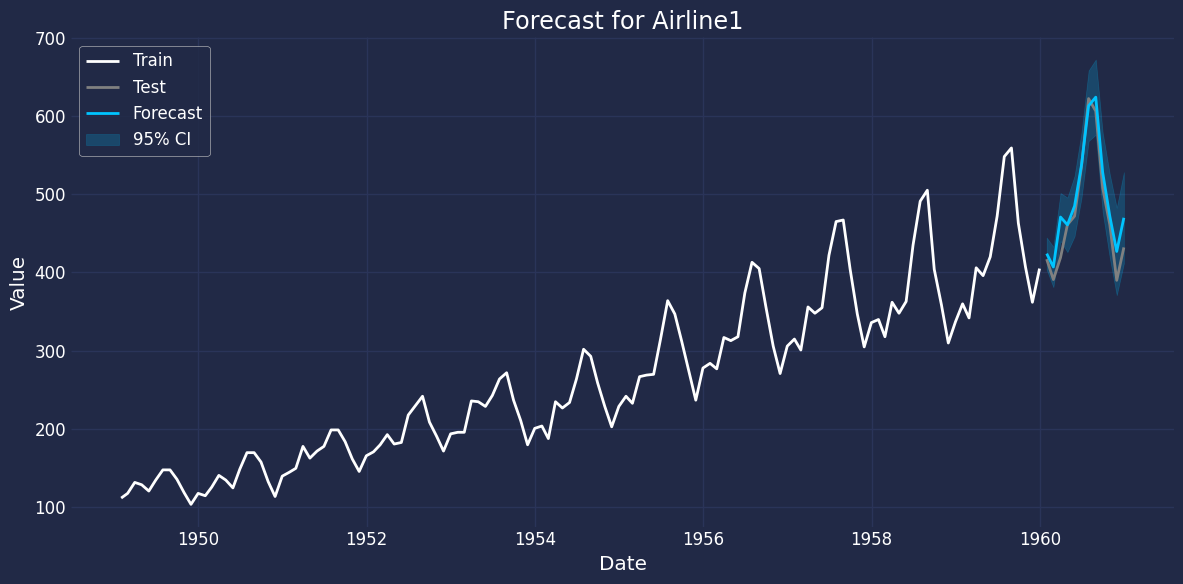

In [450]:
forecasts = sf.forecast(df=Y_train_df, h=horizon, level=[95])

uid = 'Airline1'
fcst = forecasts[forecasts['unique_id'] == uid]

# 실제값
y_train = Y_train_df[Y_train_df['unique_id'] == uid]
y_test = Y_test_df[Y_test_df['unique_id'] == uid]

# 시각화
plt.figure(figsize=(12, 6))

# 실제 학습 데이터
plt.plot(y_train['ds'], y_train['y'], label='Train', color='white')

# 실제 테스트 데이터
plt.plot(y_test['ds'], y_test['y'], label='Test', color='gray')

# 예측값 (예: AutoARIMA)
plt.plot(fcst['ds'], fcst['AutoARIMA'], label='Forecast', color='#00C4FF')

# 신뢰구간
plt.fill_between(fcst['ds'],
                 fcst['AutoARIMA-lo-95'],
                 fcst['AutoARIMA-hi-95'],
                 color='#00C4FF', alpha=0.2, label='95% CI')

plt.title(f'Forecast for {uid}', color='white')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [451]:
plot_df_sf = Y_test_df.merge(Y_hat_df, how='left', on=['unique_id', 'ds'])
plot_df_sf

,unique_id,ds,y,AutoARIMA,AutoETS,AutoTheta
0,Airline1,1960-01-31,417.0,424.083771,406.651276,409.732178
1,Airline1,1960-02-29,391.0,407.042328,401.732910,401.535187
2,Airline1,1960-03-31,419.0,470.807709,456.289642,437.742371
3,Airline1,1960-04-30,461.0,460.865143,440.870514,428.862030
4,Airline1,1960-05-31,472.0,484.851074,440.333923,433.269196
5,Airline1,1960-06-30,535.0,536.854553,496.866058,472.380524
6,Airline1,1960-07-31,622.0,612.853699,545.839111,499.200195
7,Airline1,1960-08-31,606.0,623.853882,544.672485,498.715698
8,Airline1,1960-09-30,508.0,527.853821,477.034485,458.922882
9,Airline1,1960-10-31,461.0,471.853851,412.423096,425.250885


In [452]:
model_names = ['AutoARIMA', 'AutoETS', 'AutoTheta', 'NBEATS', 'NHITS', 'PatchTST', ]
cols = ['unique_id', 'ds', 'y'] +  model_names
fcst = pd.concat([plot_df_nf, plot_df_sf.drop(columns=['unique_id', 'ds', 'y'])], axis=1)[cols]

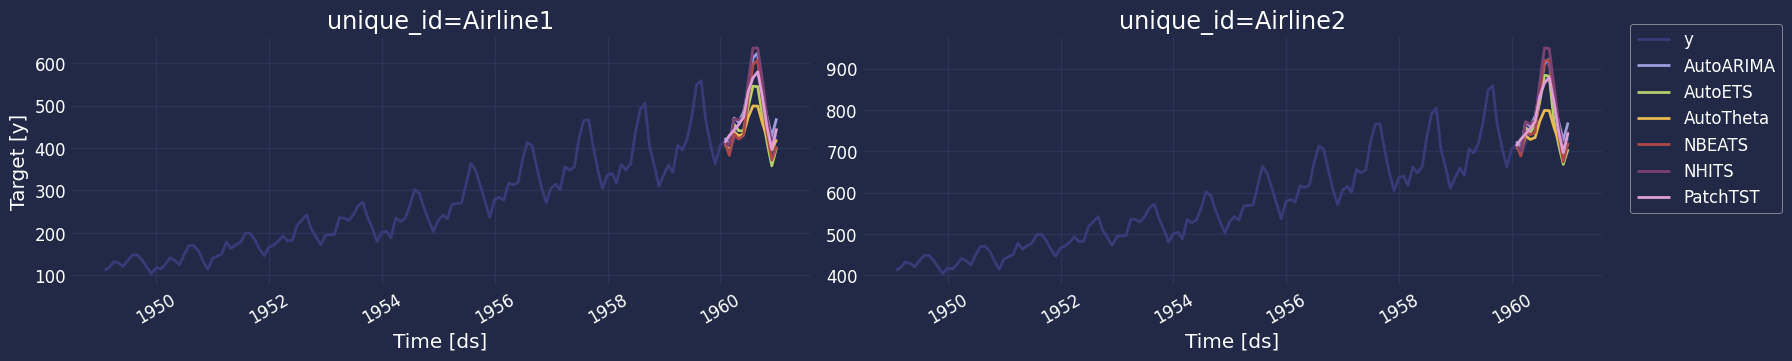

In [457]:
sf.plot(Y_train_df, fcst)
#sf.plot(Y_train_df, fcst, unique_ids=['Airline1'])

In [458]:
from functools import partial

import utilsforecast.losses as ufl
from utilsforecast.evaluation import evaluate

In [460]:
evals = evaluate(
    fcst,
    metrics=[ufl.mae, ufl.mape, partial(ufl.mase, seasonality=season_length), ufl.rmse, ufl.smape],
    train_df=Y_train_df,
).sort_values(by='unique_id')

evals

,unique_id,metric,AutoARIMA,AutoETS,AutoTheta,NBEATS,NHITS,PatchTST
0,Airline1,mae,18.515821,35.612476,41.834316,18.977989,18.940924,17.072969
2,Airline1,mape,0.041797,0.072068,0.078947,0.040839,0.039866,0.035096
4,Airline1,mase,0.608073,1.169539,1.373869,0.623251,0.622034,0.560689
6,Airline1,rmse,23.919481,40.083622,55.836357,23.128807,25.152224,23.378281
8,Airline1,smape,0.020156,0.037253,0.041942,0.021010,0.019251,0.017498
1,Airline2,mae,18.515823,22.815207,41.834316,14.203380,21.770447,17.072973
3,Airline2,mape,0.024815,0.029162,0.050160,0.018533,0.027321,0.021521
5,Airline2,mase,0.608073,0.749268,1.373869,0.466449,0.714957,0.560689
7,Airline2,rmse,23.919481,26.413132,55.836357,16.934475,28.804110,23.378286
9,Airline2,smape,0.012149,0.014744,0.026114,0.009281,0.013343,0.010769


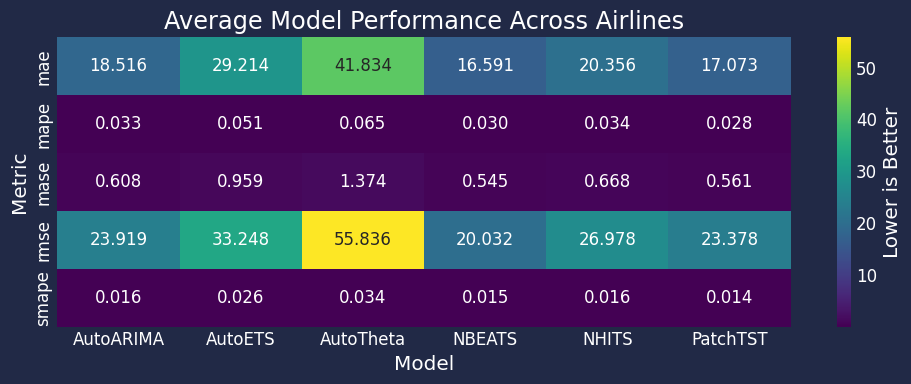

In [461]:
import seaborn as sns

# Airline1 + Airline2 평균 성능
df_avg = evals.groupby('metric')[model_names].mean()

plt.figure(figsize=(10, 4))
sns.heatmap(df_avg, annot=True, fmt=".3f", cmap='viridis', cbar_kws={'label': 'Lower is Better'})
plt.title('Average Model Performance Across Airlines')
plt.ylabel('Metric')
plt.xlabel('Model')
plt.tight_layout()
plt.show()


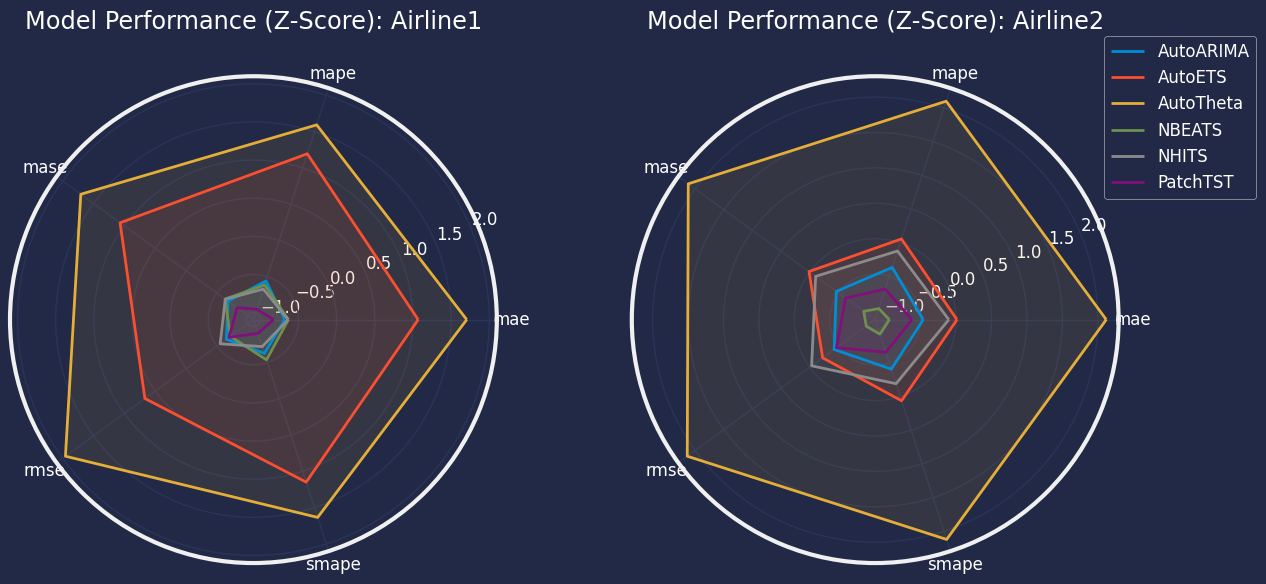

In [462]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 설정
model_names = ['AutoARIMA', 'AutoETS', 'AutoTheta', 'NBEATS', 'NHITS', 'PatchTST']
unique_ids = evals['unique_id'].unique()
metrics = ['mae', 'mape', 'mase', 'rmse', 'smape']

n_series = len(unique_ids)
n_cols = 2
n_rows = int(np.ceil(len(unique_ids) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, uid in enumerate(unique_ids):
    ax = axes[idx]

    df_series = evals[evals['unique_id'] == uid].set_index('metric').loc[metrics, model_names]

    # row-wise Z-score 정규화
    df_scaled = pd.DataFrame(index=metrics, columns=model_names, dtype=float)
    for metric in metrics:
        row = df_series.loc[metric]
        if row.isna().all():
            continue
        scaled_row = StandardScaler().fit_transform(row.dropna().values.reshape(-1, 1)).flatten()
        df_scaled.loc[metric, row.dropna().index] = scaled_row

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    for model in model_names:
        if df_scaled[model].isna().any():
            continue
        values = df_scaled[model].tolist()
        values += values[:1]
        ax.plot(angles, values, label=model, linewidth=2)
        ax.fill(angles, values, alpha=0.1)

    ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
    ax.set_title(f'Model Performance (Z-Score): {uid}', y=1.08)
    ax.grid(True)

axes[-1].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

for ax in axes[len(unique_ids):]:
    ax.axis('off')

plt.tight_layout()
plt.show()